In [39]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Cargar datos
ruta = os.path.join("..", 'Data', 'INEPernoctacionesClean11022026.csv')

df = pd.read_csv(ruta, parse_dates=["Fecha"])

In [40]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Totales Territoriales             1512 non-null   object        
 1   Comunidades y Ciudades Autónomas  1488 non-null   object        
 2   Provincias                        1032 non-null   object        
 3   Fecha                             1512 non-null   datetime64[ns]
 4   Año                               1512 non-null   int64         
 5   Mes                               1512 non-null   int64         
 6   Mes_nombre                        1512 non-null   object        
 7   media_pernoctaciones              1512 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 94.6+ KB


Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Fecha', 'Año', 'Mes', 'Mes_nombre',
       'media_pernoctaciones'],
      dtype='object')

In [41]:
df['Provincias'].unique()

array([nan, 'Almerï¿½a', 'Cï¿½diz', 'Cï¿½rdoba', 'Granada', 'Huelva',
       'Jaï¿½n', 'Mï¿½laga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza',
       'Palmas, Las', 'Santa Cruz de Tenerife', 'ï¿½vila', 'Burgos',
       'Leï¿½n', 'Palencia', 'Salamanca', 'Segovia', 'Soria',
       'Valladolid', 'Zamora', 'Albacete', 'Ciudad Real', 'Cuenca',
       'Guadalajara', 'Toledo', 'Barcelona', 'Girona', 'Lleida',
       'Tarragona', 'Alicante/Alacant', 'Castellï¿½n/Castellï¿½',
       'Valencia/Valï¿½ncia', 'Badajoz', 'Cï¿½ceres', 'Coruï¿½a, A',
       'Lugo', 'Ourense', 'Pontevedra', 'Araba/ï¿½lava', 'Bizkaia',
       'Gipuzkoa'], dtype=object)

In [42]:
df['Provincias'] = df['Provincias'].replace('Mï¿½laga', 'Málaga')

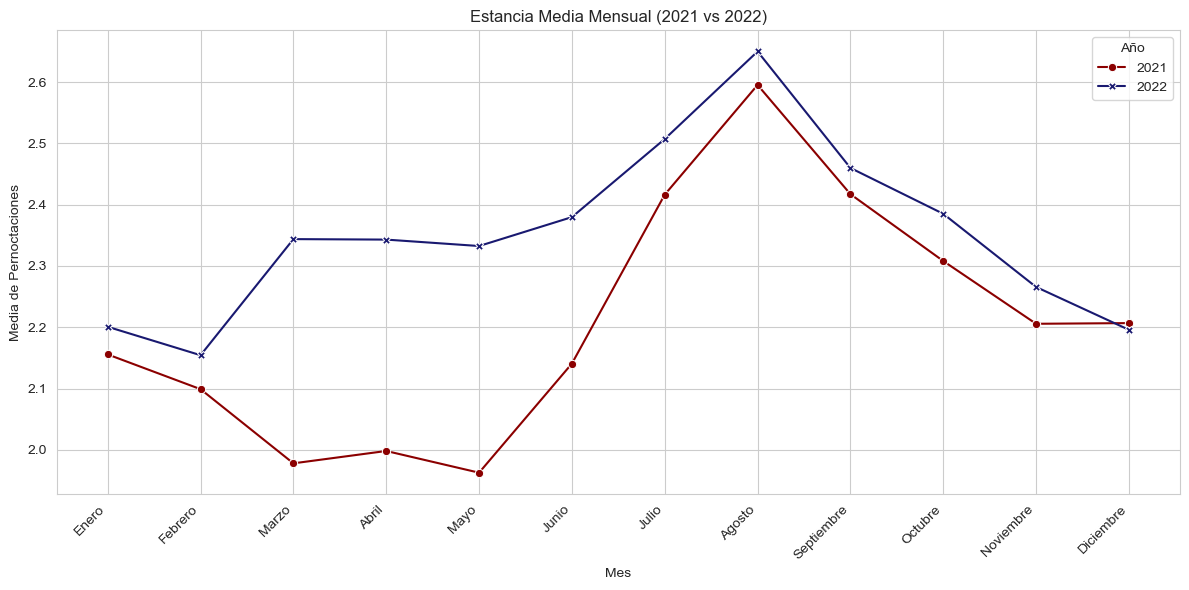

In [43]:
# 1. DEFINIR EL ORDEN DE LOS MESES
# Creamos una lista manual para decirle a Python cuál es el orden correcto del calendario.
orden_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

# 2. APLICAR EL ORDEN A LOS DATOS
# Convertimos la columna 'Mes_nombre' en una categoría ordenada.
# Esto evita que Python ordene alfabéticamente (Abril, Agosto...) y use el orden lógico.
df['Mes_nombre'] = pd.Categorical(
    df['Mes_nombre'], 
    categories=orden_meses, 
    ordered=True
)

# 3. CONFIGURACIÓN DEL GRÁFICO
plt.figure(figsize=(12, 6))

# Colores personalizados (Rojo Oscuro y Azul Marino)
colores_oscuros = ["#8B0000", "#191970"] 

sns.lineplot(
    data=df, 
    x='Mes_nombre',            # <--- Usamos tu columna con los nombres
    y='media_pernoctaciones',  # Asegúrate de que este nombre sea igual al de tu Excel
    hue='Año', 
    palette=colores_oscuros,   # Aplicamos los colores oscuros
    style='Año', 
    markers=True,              # Pone los puntos en cada mes
    dashes=False,              # Líneas sólidas (sin guiones)
    errorbar=None              # <--- IMPORTANTE: Esto elimina la sombra (tercer color)
)

# 4. AJUSTES DE ETIQUETAS Y TÍTULOS
plt.title("Estancia Media Mensual (2021 vs 2022)")
plt.xlabel("Mes")
plt.ylabel("Media de Pernoctaciones")

# Rotamos los nombres de los meses 45 grados
# ha='right' alinea el texto a la derecha para que coincida exactamente con la marca del eje
plt.xticks(rotation=45, ha='right')

# Ajusta los márgenes automáticamente para que no se corte nada
plt.tight_layout()

plt.show()

In [44]:
max_row = df.loc[df["media_pernoctaciones"].idxmax()]
print(max_row)

Totales Territoriales                    Total Nacional
Comunidades y Ciudades Autónomas               Canarias
Provincias                                  Palmas, Las
Fecha                               2022-01-01 00:00:00
Año                                                2022
Mes                                                   1
Mes_nombre                                        Enero
media_pernoctaciones                               7.48
Name: 419, dtype: object


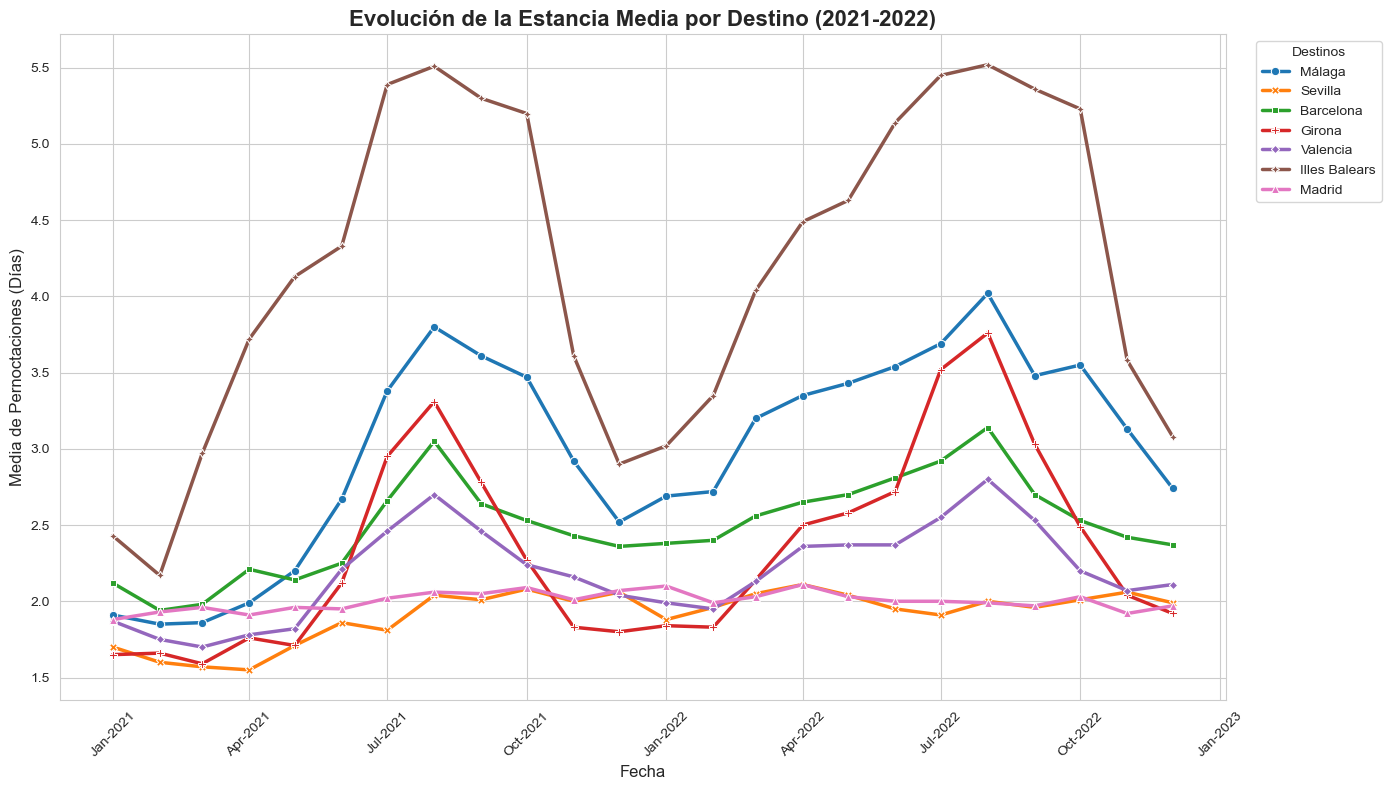

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

keywords_prov = ['Barcelona', 'Girona', 'Valencia', 'Málaga', 'Malaga', 'Sevilla']
df_prov = df[df['Provincias'].str.contains('|'.join(keywords_prov), na=False, case=False)].copy()
df_prov['Fuente_Original'] = df_prov['Provincias']  # Guardamos el nombre original

# GRUPO B: Ciudades ubicadas en la columna 'Comunidades y Ciudades Autónomas'
# (Madrid, Comunidad de; Balears, Illes)
keywords_com = ['Madrid', 'Balears']
df_com = df[df['Comunidades y Ciudades Autónomas'].str.contains('|'.join(keywords_com), na=False, case=False)].copy()
df_com['Fuente_Original'] = df_com['Comunidades y Ciudades Autónomas'] # Guardamos el nombre original

# Unificar ambos grupos en un solo DataFrame
df_final = pd.concat([df_prov, df_com])

# ---------------------------------------------------------
# PASO 3: ESTANDARIZACIÓN DE NOMBRES (LIMPIEZA DE ETIQUETAS)
# ---------------------------------------------------------
# Función para limpiar nombres complejos como "Valencia/València" o "Madrid, Comunidad de"

def normalizar_nombre(texto):
    if pd.isna(texto): return "Desconocido"
    t = str(texto).lower()
    
    if 'valencia' in t or 'valència' in t: return 'Valencia'
    if 'madrid' in t: return 'Madrid'
    if 'balears' in t: return 'Illes Balears'
    if 'barcelona' in t: return 'Barcelona'
    if 'girona' in t: return 'Girona'
    if 'malaga' in t or 'málaga' in t: return 'Málaga'
    if 'sevilla' in t: return 'Sevilla'
    
    return texto.title()

# Aplicar la función para crear la columna limpia 'Destino'
df_final['Destino'] = df_final['Fuente_Original'].apply(normalizar_nombre)

# ---------------------------------------------------------
# PASO 4: VISUALIZACIÓN DE LA TENDENCIA (GRÁFICO)
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear el gráfico de líneas
grafico = sns.lineplot(
    data=df_final,
    x='Fecha',
    y='media_pernoctaciones',
    hue='Destino',
    style='Destino', 
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette='tab10' 
)

# Títulos y Etiquetas en Español
plt.title('Evolución de la Estancia Media por Destino (2021-2022)', fontsize=16, fontweight='bold')
plt.ylabel('Media de Pernoctaciones (Días)', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.legend(title='Destinos', bbox_to_anchor=(1.02, 1), loc='upper left')

# Formato del eje X (Mes-Año)
grafico.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

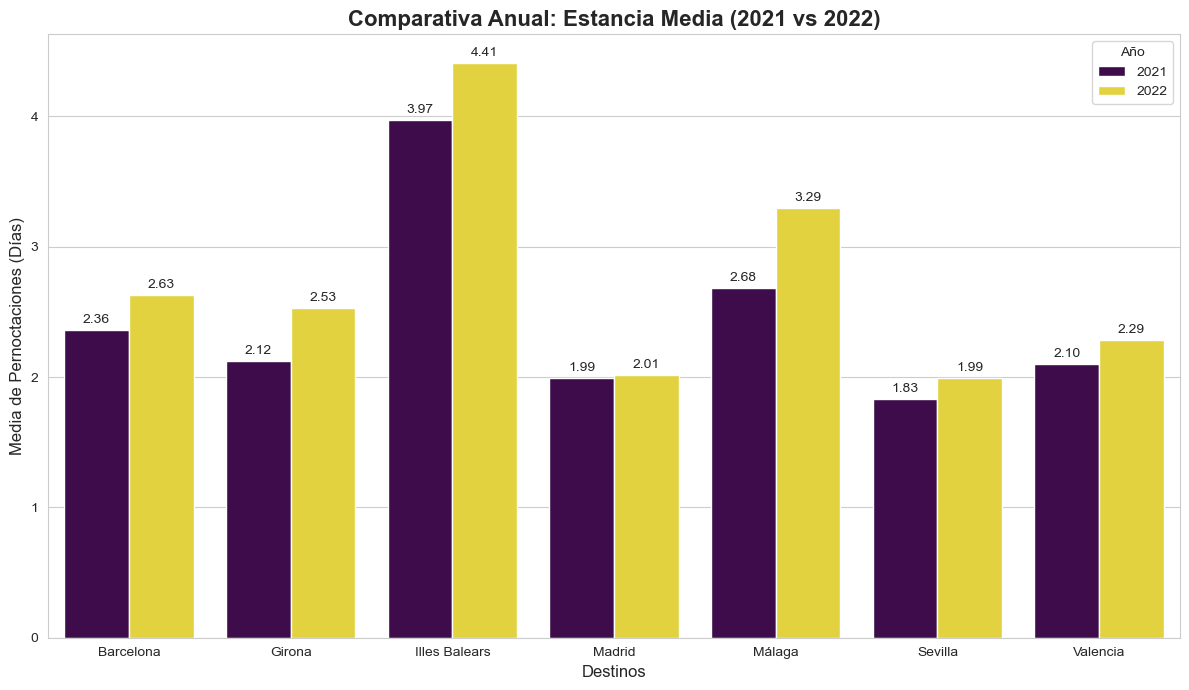


--- TABLA DE VARIACIÓN PORCENTUAL (2021 vs 2022) ---
Año            2021  2022  Variación (%)
Destino                                 
Barcelona      2.36  2.63          11.55
Girona         2.12  2.53          19.43
Illes Balears  3.97  4.41          10.97
Madrid         1.99  2.01           1.05
Málaga         2.68  3.30          22.87
Sevilla        1.83  1.99           8.78
Valencia       2.10  2.29           8.89


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# PASO 1: FILTRADO DE DESTINOS DE INTERÉS
# ---------------------------------------------------------
# Seleccionamos determinadas provincias
keywords_prov = ['Barcelona', 'Girona', 'Valencia', 'Málaga', 'Malaga', 'Sevilla']
df_prov = df[df['Provincias'].str.contains('|'.join(keywords_prov), 
                                           na=False, case=False)].copy()

# Guardamos el nombre original para luego estandarizarlo
df_prov['Fuente_Original'] = df_prov['Provincias']

# Seleccionamos ciudades que aparecen en la columna 
# "Comunidades y Ciudades Autónomas"
keywords_com = ['Madrid', 'Balears']
df_com = df[df['Comunidades y Ciudades Autónomas']
            .str.contains('|'.join(keywords_com), 
                          na=False, case=False)].copy()

df_com['Fuente_Original'] = df_com['Comunidades y Ciudades Autónomas']

# Unimos ambos subconjuntos en un único DataFrame
df_final = pd.concat([df_prov, df_com])

# ---------------------------------------------------------
# PASO 2: ESTANDARIZACIÓN DE NOMBRES DE DESTINO
# ---------------------------------------------------------
# Creamos una función para limpiar y homogeneizar los nombres.
# Esto evita duplicidades como:
# "Malaga" / "Málaga"
# "Valencia/València"
# "Madrid, Comunidad de"

def normalizar_nombre(texto):
    if pd.isna(texto): 
        return "Desconocido"
    
    t = str(texto).lower()
    
    if 'valencia' in t:
        return 'Valencia'
    if 'madrid' in t:
        return 'Madrid'
    if 'balears' in t:
        return 'Illes Balears'
    if 'barcelona' in t:
        return 'Barcelona'
    if 'girona' in t:
        return 'Girona'
    if 'malaga' in t or 'málaga' in t:
        return 'Málaga'
    if 'sevilla' in t:
        return 'Sevilla'
    
    return texto.title()

# Aplicamos la función para crear la nueva columna "Destino"
df_final['Destino'] = df_final['Fuente_Original'].apply(normalizar_nombre)

# ---------------------------------------------------------
# PASO 3: AGRUPACIÓN POR AÑO (CÁLCULO DE LA MEDIA ANUAL)
# ---------------------------------------------------------
# Calculamos la media anual de pernoctaciones por destino.
# Esto permite comparar directamente 2021 vs 2022.

df_comparativa = (
    df_final
    .groupby(['Destino', 'Año'])['media_pernoctaciones']
    .mean()
    .reset_index()
)

# ---------------------------------------------------------
# PASO 4: VISUALIZACIÓN COMPARATIVA (GRÁFICO DE BARRAS)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Creamos un gráfico de barras agrupadas:
# - Eje X: Destinos
# - Eje Y: Media de pernoctaciones
# - Hue: Año (2021 y 2022 lado a lado)

grafico = sns.barplot(
    data=df_comparativa,
    x='Destino',
    y='media_pernoctaciones',
    hue='Año',
    palette='viridis'  # Paleta profesional y visualmente clara
)

# Títulos y etiquetas
plt.title('Comparativa Anual: Estancia Media (2021 vs 2022)', 
          fontsize=16, fontweight='bold')

plt.ylabel('Media de Pernoctaciones (Días)', fontsize=12)
plt.xlabel('Destinos', fontsize=12)

# Añadimos las etiquetas numéricas encima de cada barra
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title='Año', loc='upper right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PASO 5: CÁLCULO DE LA VARIACIÓN PORCENTUAL
# ---------------------------------------------------------
# Creamos una tabla comparativa para calcular la variación
# porcentual entre 2021 y 2022.

pivot_variacion = df_comparativa.pivot(
    index='Destino', 
    columns='Año', 
    values='media_pernoctaciones'
)

# Fórmula de variación porcentual:
# ((Valor_2022 - Valor_2021) / Valor_2021) * 100

pivot_variacion['Variación (%)'] = (
    (pivot_variacion[2022] - pivot_variacion[2021]) 
    / pivot_variacion[2021]
) * 100

print("\n--- TABLA DE VARIACIÓN PORCENTUAL (2021 vs 2022) ---")
print(pivot_variacion.round(2))

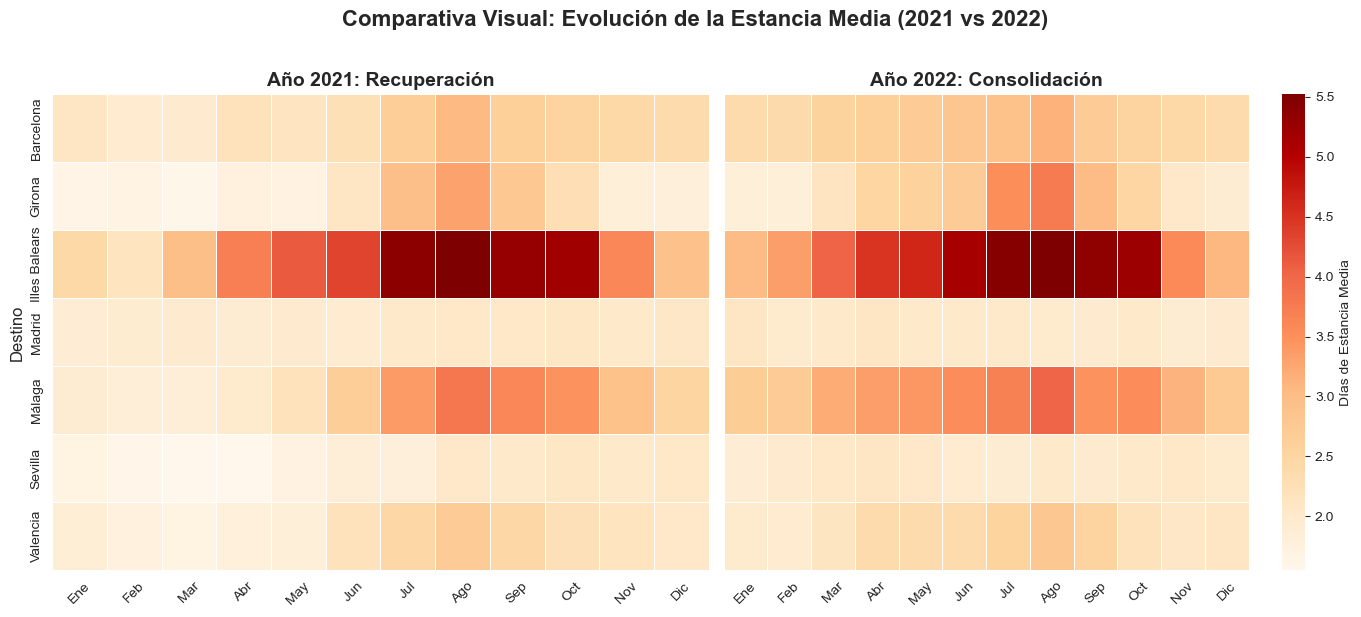

In [47]:
# ---------------------------------------------------------
# FILTRADO DE DESTINOS DE INTERÉS
# ---------------------------------------------------------

# Seleccionamos determinadas provincias
keywords_prov = ['Barcelona', 'Girona', 'Valencia', 'Málaga', 'Malaga', 'Sevilla']
df_prov = df[df['Provincias'].str.contains('|'.join(keywords_prov),
                                           na=False, case=False)].copy()

df_prov['Fuente_Original'] = df_prov['Provincias']

# Seleccionamos Madrid e Illes Balears desde la columna de Comunidades
keywords_com = ['Madrid', 'Balears']
df_com = df[df['Comunidades y Ciudades Autónomas']
            .str.contains('|'.join(keywords_com),
                          na=False, case=False)].copy()

df_com['Fuente_Original'] = df_com['Comunidades y Ciudades Autónomas']

# Unimos ambos subconjuntos en un único DataFrame
df_final = pd.concat([df_prov, df_com])

# ---------------------------------------------------------
# ESTANDARIZACIÓN DE NOMBRES DE DESTINO
# ---------------------------------------------------------
# Esta función evita duplicidades como:
# "Malaga" / "Málaga"
# "Madrid, Comunidad de"
# "Valencia/València"

def normalizar_nombre(texto):
    if pd.isna(texto):
        return "Desconocido"
    
    t = str(texto).lower()
    
    if 'valencia' in t:
        return 'Valencia'
    if 'madrid' in t:
        return 'Madrid'
    if 'balears' in t:
        return 'Illes Balears'
    if 'barcelona' in t:
        return 'Barcelona'
    if 'girona' in t:
        return 'Girona'
    if 'malaga' in t or 'málaga' in t:
        return 'Málaga'
    if 'sevilla' in t:
        return 'Sevilla'
    
    return texto.title()

df_final['Destino'] = df_final['Fuente_Original'].apply(normalizar_nombre)

# ---------------------------------------------------------
# PASO 2: CREACIÓN DE TABLAS PIVOT PARA 2021 Y 2022
# ---------------------------------------------------------

# Calculamos el valor mínimo y máximo global para mantener
# la misma escala de colores en ambos mapas de calor.
global_min = df_final['media_pernoctaciones'].min()
global_max = df_final['media_pernoctaciones'].max()

# Tabla para 2021
df_2021 = df_final[df_final['Año'] == 2021].pivot_table(
    index='Destino',
    columns='Mes',
    values='media_pernoctaciones'
)

# Tabla para 2022
df_2022 = df_final[df_final['Año'] == 2022].pivot_table(
    index='Destino',
    columns='Mes',
    values='media_pernoctaciones'
)

# Etiquetas abreviadas de los meses en español
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# ---------------------------------------------------------
# PASO 3: VISUALIZACIÓN COMPARATIVA (HEATMAPS LADO A LADO)
# ---------------------------------------------------------

# Creamos una figura con 1 fila y 2 columnas
# sharey=True permite compartir el eje Y (mismos destinos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------------------------
# HEATMAP 2021 (IZQUIERDA)
# -------------------------
sns.heatmap(
    df_2021,
    ax=axes[0],
    cmap='OrRd',                 # Escala de color naranja-rojo
    vmin=global_min,
    vmax=global_max,             # Misma escala para comparar correctamente
    cbar=False,                  # Sin barra de color aquí (evita duplicación)
    annot=False,
    linewidths=0.5
)

axes[0].set_title('Año 2021: Recuperación',
                  fontsize=14, fontweight='bold')

axes[0].set_xlabel('')
axes[0].set_xticklabels(meses_labels, rotation=45)
axes[0].set_ylabel('Destino', fontsize=12)

# -------------------------
# HEATMAP 2022 (DERECHA)
# -------------------------
sns.heatmap(
    df_2022,
    ax=axes[1],
    cmap='OrRd',
    vmin=global_min,
    vmax=global_max,             # Misma escala que 2021
    cbar=True,                   # Solo aquí mostramos la barra de color
    cbar_kws={'label': 'Días de Estancia Media'},
    annot=False,
    linewidths=0.5
)

axes[1].set_title('Año 2022: Consolidación',
                  fontsize=14, fontweight='bold')

axes[1].set_xlabel('')
axes[1].set_xticklabels(meses_labels, rotation=45)
axes[1].set_ylabel('')  # No repetimos el eje Y

# Título general de la figura
plt.suptitle(
    'Comparativa Visual: Evolución de la Estancia Media (2021 vs 2022)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()